### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [873]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [874]:
data = pd.read_csv('data/coupons.csv')

In [875]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [876]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [877]:
# car column has negligable data so i am removing it
data = data.drop(columns=['car']) 

#getting the information about the fields that have null values
#data.isnull().sum()
#data.value_counts('Bar', dropna=False)
#data.value_counts('CoffeeHouse', dropna=False)
#data.value_counts('CarryAway', dropna=False)
#data.value_counts('RestaurantLessThan20', dropna=False)
#data.value_counts('Restaurant20To50', dropna=False)
#data.shape[0]
#data.isnull().sum()
#data[data.duplicated() == True]

#filling the nulls with "never' value, and drop dublicates
values = {"Bar": "never", "CoffeeHouse": "never", "CarryAway": "never", "RestaurantLessThan20": "never", "Restaurant20To50": "never"}
data =data.fillna(value= values).drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12610 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12610 non-null  object
 1   passanger             12610 non-null  object
 2   weather               12610 non-null  object
 3   temperature           12610 non-null  int64 
 4   time                  12610 non-null  object
 5   coupon                12610 non-null  object
 6   expiration            12610 non-null  object
 7   gender                12610 non-null  object
 8   age                   12610 non-null  object
 9   maritalStatus         12610 non-null  object
 10  has_children          12610 non-null  int64 
 11  education             12610 non-null  object
 12  occupation            12610 non-null  object
 13  income                12610 non-null  object
 14  Bar                   12610 non-null  object
 15  CoffeeHouse           12610 non-null  obj

4. What proportion of the total observations chose to accept the coupon?



In [878]:
#data.value_counts('Y', dropna=False)
data.query('Y==1')['Y'].count()/data.shape[0]

np.float64(0.5675654242664552)

5. Use a bar plot to visualize the `coupon` column.

<Axes: xlabel='count', ylabel='Y'>

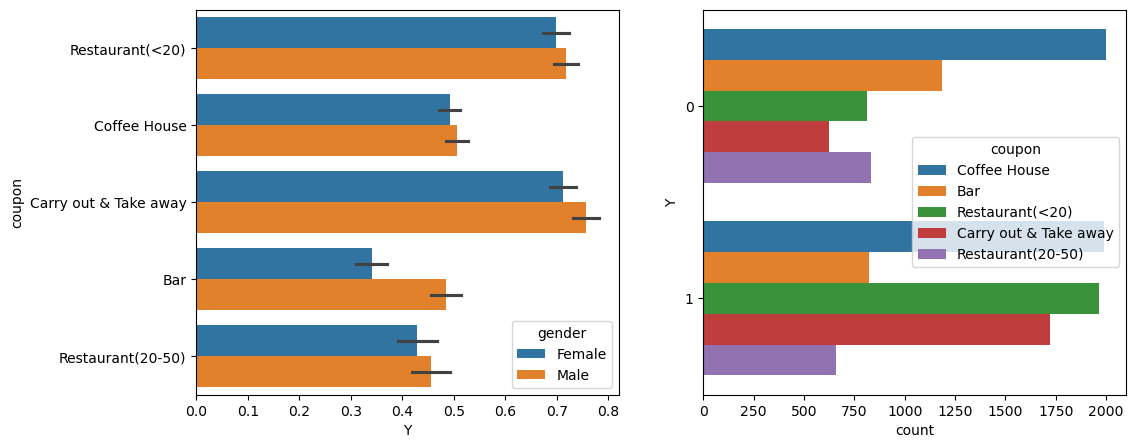

In [879]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.barplot(data, x="Y", y="coupon", hue="gender")

plt.subplot(122)
sns.countplot(data, y="Y", hue="coupon")

6. Use a histogram to visualize the temperature column.

array([[<Axes: title={'center': 'temperature'}>]], dtype=object)

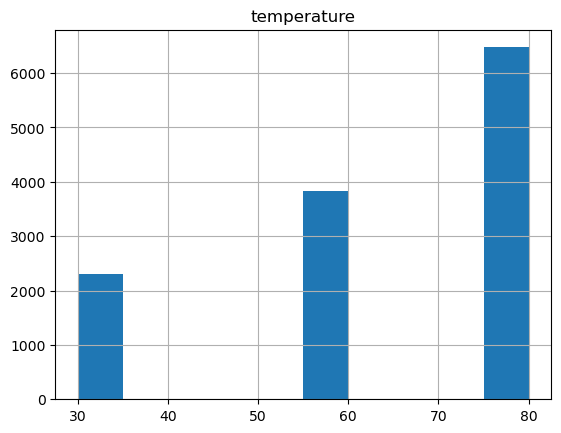

In [880]:
data.hist(column=["temperature"])

<Axes: xlabel='passanger', ylabel='temperature'>

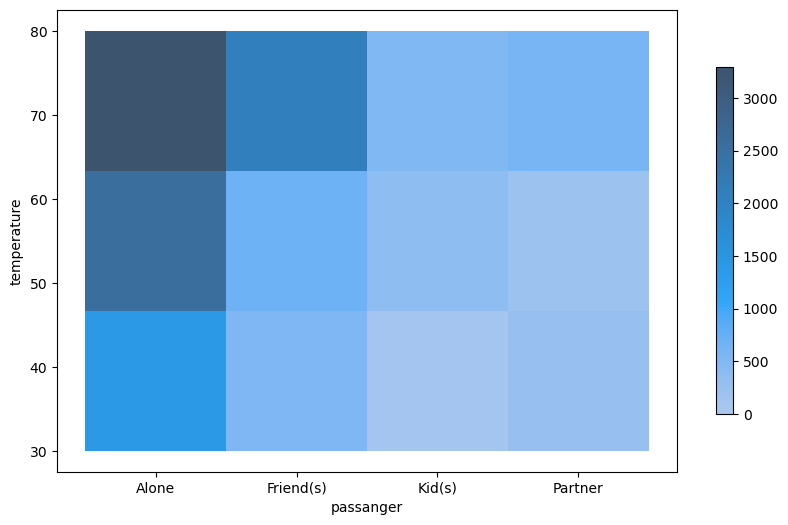

In [881]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data, x="passanger", y="temperature",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
    ax=ax
)


<Axes: xlabel='age', ylabel='temperature'>

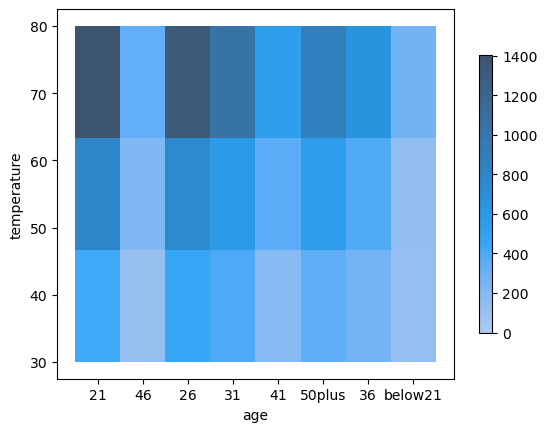

In [882]:
sns.histplot(
    data, x="age", y="temperature",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)

<function matplotlib.pyplot.show(close=None, block=None)>

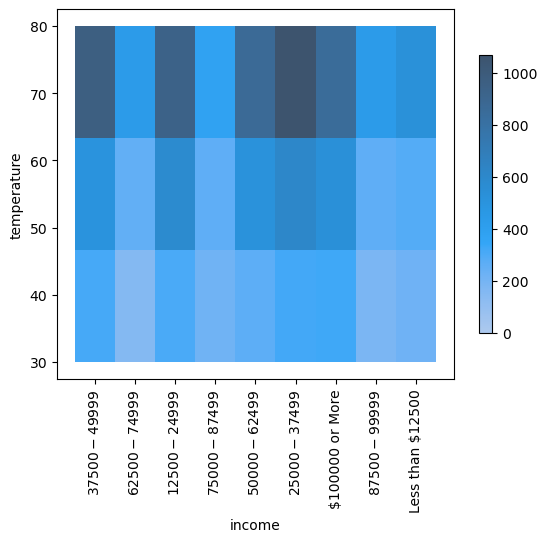

In [883]:
ax =sns.histplot(
    data, x="income", y="temperature",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)
plt.xticks(rotation=90)
plt.show

<Axes: xlabel='time', ylabel='temperature'>

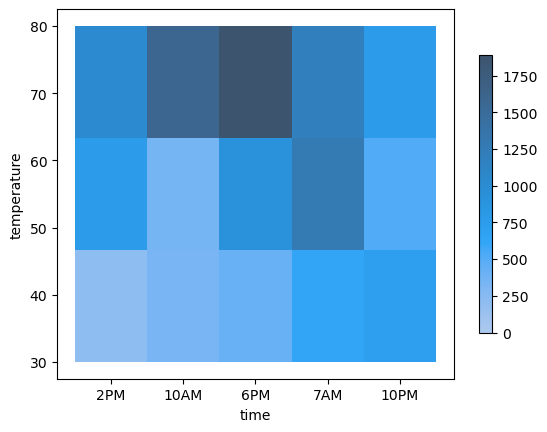

In [884]:
sns.histplot(
    data, x="time", y="temperature",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)

<Axes: xlabel='RestaurantLessThan20', ylabel='temperature'>

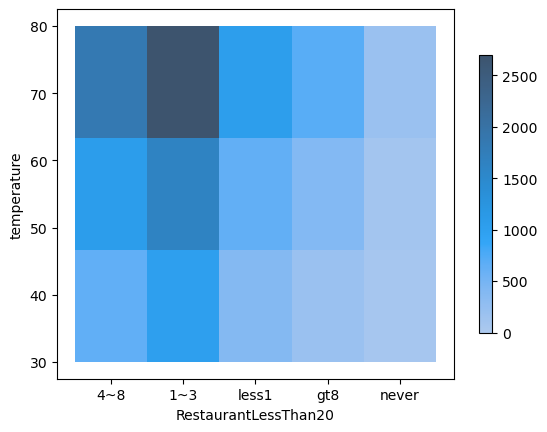

In [885]:
sns.histplot(
    data, x="RestaurantLessThan20", y="temperature",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)

<Axes: xlabel='Restaurant20To50', ylabel='temperature'>

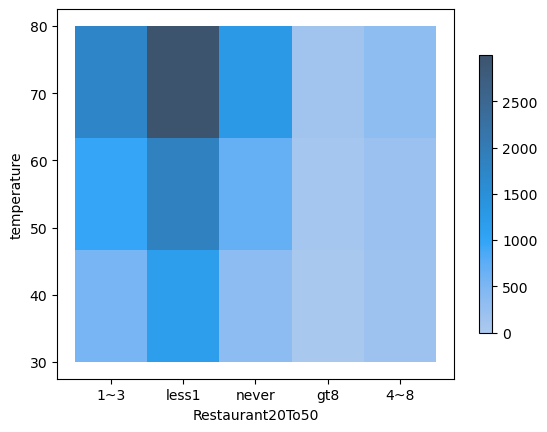

In [886]:
sns.histplot(
    data, x="Restaurant20To50", y="temperature",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)

<Axes: xlabel='direction_same', ylabel='temperature'>

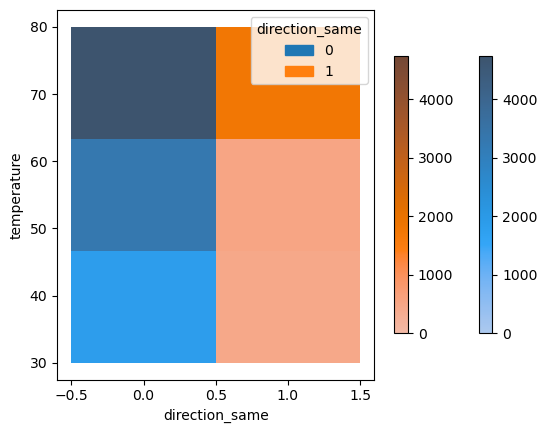

In [887]:
sns.histplot(
    data, x="direction_same", y="temperature", hue="direction_same",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)

<Axes: xlabel='direction_opp', ylabel='temperature'>

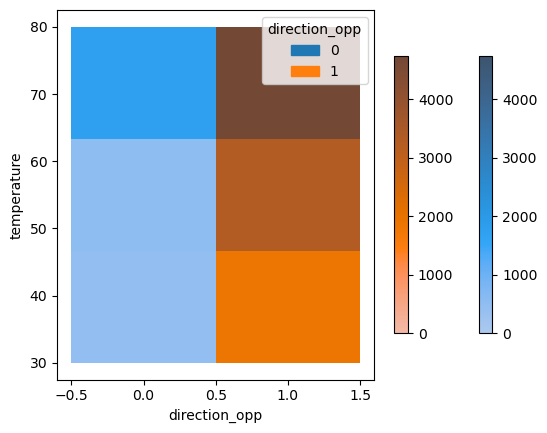

In [888]:
sns.histplot(
    data, x="direction_opp", y="temperature", hue="direction_opp",
    bins=3, discrete=(True, False),
    cbar=True, cbar_kws=dict(shrink=.75),
)

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [889]:
data.value_counts('coupon', dropna=False)

coupon
Coffee House             3989
Restaurant(<20)          2779
Carry out & Take away    2344
Bar                      2010
Restaurant(20-50)        1488
Name: count, dtype: int64

In [890]:
data_BarCoupon = data.query('coupon == "Bar"')
data_BarCoupon

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


In [891]:
data_BarCoupon.query('Y==1')['Y'].count()/data_BarCoupon.shape[0]

np.float64(0.4099502487562189)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [892]:
data_BarCoupon.value_counts('Bar', dropna=False)

Bar
never    851
less1    563
1~3      397
4~8      150
gt8       49
Name: count, dtype: int64

In [893]:
# assuming fewer includes never
fewerthan3_Or3 = ['never', 'less1', '1~3']
bar_3Orfewer_count = data_BarCoupon.query('Bar in @fewerthan3_Or3 and Y == 1')['Y'].count()
bar_3Orfewer_count
morethan3_count = data_BarCoupon.query('Bar not in @fewerthan3_Or3 and Y == 1')['Y'].count()
morethan3_count
acceptance_rate_fewer3included = bar_3Orfewer_count/data_BarCoupon.query('Y == 1')['Y'].count()
acceptance_rate_morethan3 = morethan3_count/data_BarCoupon.query('Y == 1')['Y'].count()

print('Bar accceptance rate for 3 or fewer is: ' + acceptance_rate_fewer3included.astype(str))
print('Bar accceptance rate for more than 3  : ' + acceptance_rate_morethan3.astype(str))
print('Acceptance rate : ' + (acceptance_rate_fewer3included/acceptance_rate_morethan3).astype(str))

# Not accepring the coupon
bar_3Orfewer_count = data_BarCoupon.query('Bar in @fewerthan3_Or3 and Y == 0')['Y'].count()
bar_3Orfewer_count
morethan3_count = data_BarCoupon.query('Bar not in @fewerthan3_Or3 and Y == 0')['Y'].count()
morethan3_count
acceptance_rate_fewer3included = bar_3Orfewer_count/data_BarCoupon.query('Y == 0')['Y'].count()
acceptance_rate_morethan3 = morethan3_count/data_BarCoupon.query('Y == 0')['Y'].count()

print('Bar not accceptance rate for 3 or fewer is: ' + acceptance_rate_fewer3included.astype(str))
print('Bar not accceptance rate for more than 3  : ' + acceptance_rate_morethan3.astype(str))
print('Not Acceptance rate : ' + (acceptance_rate_fewer3included/acceptance_rate_morethan3).astype(str))

Bar accceptance rate for 3 or fewer is: 0.8143203883495146
Bar accceptance rate for more than 3  : 0.18567961165048544
Acceptance rate : 4.38562091503268
Bar not accceptance rate for 3 or fewer is: 0.9612141652613828
Bar not accceptance rate for more than 3  : 0.0387858347386172
Not Acceptance rate : 24.782608695652176


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [894]:
# when defining specification, its is beteere to not use terms like "others", but rather clearly what others it constitutes.
# I am going to assume that "other" means all the dataset outside the specified criterias
data_BarCoupon.value_counts('age', dropna=False)

age
21         417
26         395
31         336
50plus     283
36         209
41         178
46         105
below21     87
Name: count, dtype: int64

In [895]:
# The data is confusing as it has field "less1", the question is how can someone attend a bar less than one since its etither you go or dont.
# I am making an assumption that 'less1' represent one time visit , and '1~3' to be more than 1 to 3 times
more_than_1 = ['1~3', '4~8', 'gt8']
age_more_than_25 = ['26', '31', '36', '41', '46', '50plus']
bar_More_than_one = data_BarCoupon.query('Bar in @more_than_1 and Y == 1 and age in @age_more_than_25')['Y'].count()
bar_others = data_BarCoupon.query('Bar in ["never", "less1"] and Y == 1 and age in ["below21", "21"]')['Y'].count()

acceptance_rate_bar_More_than_one = bar_More_than_one/data_BarCoupon.query('Y == 1')['Y'].count()
acceptance_rate_bar_others = bar_others/data_BarCoupon.query('Y == 1')['Y'].count()

print('Bar accceptance rate going more than once and over 25            : ' + acceptance_rate_bar_More_than_one.astype(str))
print('Bar accceptance rate going one time or less with age less than 25: ' + acceptance_rate_bar_others.astype(str))
print('Acceptance rate : ' + (bar_More_than_one/bar_others).astype(str))

# Not accepting the coupon
bar_More_than_one = data_BarCoupon.query('Bar in @more_than_1 and Y == 0 and age in @age_more_than_25')['Y'].count()
bar_others = data_BarCoupon.query('Bar in ["never", "less1"] and Y == 0 and age in ["below21", "21"]')['Y'].count()

acceptance_rate_bar_More_than_one = bar_More_than_one/data_BarCoupon.query('Y == 0')['Y'].count()
acceptance_rate_bar_others = bar_others/data_BarCoupon.query('Y == 0')['Y'].count()

print('Bar not accceptance rate going more than once and over 25            : ' + acceptance_rate_bar_More_than_one.astype(str))
print('Bar not accceptance rate going one time or less with age less than 25: ' + acceptance_rate_bar_others.astype(str))
print('Not Acceptance rate : ' + (bar_More_than_one/bar_others).astype(str))

Bar accceptance rate going more than once and over 25            : 0.35436893203883496
Bar accceptance rate going one time or less with age less than 25: 0.15655339805825244
Acceptance rate : 2.2635658914728682
Bar not accceptance rate going more than once and over 25            : 0.10792580101180438
Bar not accceptance rate going one time or less with age less than 25: 0.16779089376053963
Not Acceptance rate : 0.6432160804020101


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [896]:
# This is not a clear requirement, are we comparing between what is defined and all the others who are not in the selected criteria. 
# it would be good to be clear what the comparison is about 
print(data_BarCoupon.value_counts('passanger', dropna=False))
print(data_BarCoupon.value_counts('occupation', dropna=False))

passanger
Alone        1198
Friend(s)     335
Partner       273
Kid(s)        204
Name: count, dtype: int64
occupation
Unemployed                                   301
Student                                      251
Computer & Mathematical                      229
Sales & Related                              178
Education&Training&Library                   140
Management                                   115
Office & Administrative Support              105
Arts Design Entertainment Sports & Media     100
Business & Financial                          89
Retired                                       75
Food Preparation & Serving Related            48
Community & Social Services                   44
Healthcare Support                            44
Healthcare Practitioners & Technical          41
Transportation & Material Moving              35
Legal                                         34
Protective Service                            27
Architecture & Engineering                    27

In [897]:
more_than_1 = ['1~3', '4~8', 'gt8']
bar_Morethan1_nokid_noFarm = data_BarCoupon.query('Bar in @more_than_1 and Y == 1 and passanger not in "Kid(s)" and occupation not in "Farming Fishing & Forestry"')
bar_1OrLess_kid_Farm = data_BarCoupon.query('Bar not in @more_than_1 and Y == 1 and passanger in "Kid(s)" and occupation in "Farming Fishing & Forestry"')

acceptance_rate_bar_Morethan1_nokid_noFarm = bar_Morethan1_nokid_noFarm['Y'].count()/data_BarCoupon.query('Y == 1')['Y'].count()
acceptance_bar_1OrLess_kid_Farm = bar_1OrLess_kid_Farm['Y'].count()/data_BarCoupon.query('Y == 1')['Y'].count()


print('Bar accceptance rate going more than once, no kids, not farming : ' + acceptance_rate_bar_Morethan1_nokid_noFarm.astype(str))
print('Bar accceptance rate going once or less, with kids and farming : ' + acceptance_bar_1OrLess_kid_Farm .astype(str))
print('Acceptance rate : ' + (acceptance_rate_bar_Morethan1_nokid_noFarm/acceptance_bar_1OrLess_kid_Farm).astype(str))

# Not accepting the coupon
bar_Morethan1_nokid_noFarm = data_BarCoupon.query('Bar in @more_than_1 and Y == 0 and passanger not in "Kid(s)" and occupation not in "Farming Fishing & Forestry"')
bar_1OrLess_kid_Farm = data_BarCoupon.query('Bar not in @more_than_1 and Y == 0 and passanger in "Kid(s)" and occupation in "Farming Fishing & Forestry"')

acceptance_rate_bar_Morethan1_nokid_noFarm = bar_Morethan1_nokid_noFarm['Y'].count()/data_BarCoupon.query('Y == 0')['Y'].count()
acceptance_bar_1OrLess_kid_Farm = bar_1OrLess_kid_Farm['Y'].count()/data_BarCoupon.query('Y == 0')['Y'].count()


print('Bar not accceptance rate going more than once, no kids, not farming : ' + acceptance_rate_bar_Morethan1_nokid_noFarm.astype(str))
print('Bar not accceptance rate going once or less, with kids and farming : ' + acceptance_bar_1OrLess_kid_Farm .astype(str))
print('Not Acceptance rate : ' + (acceptance_rate_bar_Morethan1_nokid_noFarm/acceptance_bar_1OrLess_kid_Farm).astype(str))


Bar accceptance rate going more than once, no kids, not farming : 0.47694174757281554
Bar accceptance rate going once or less, with kids and farming : 0.0012135922330097086
Acceptance rate : 393.00000000000006
Bar not accceptance rate going more than once, no kids, not farming : 0.13322091062394603
Bar not accceptance rate going once or less, with kids and farming : 0.0016863406408094434
Not Acceptance rate : 79.0


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [898]:
data_BarCoupon.value_counts('RestaurantLessThan20', dropna=False)
data_BarCoupon.value_counts('income', dropna=False)

income
$25000 - $37499     318
$100000 or More     288
$12500 - $24999     288
$37500 - $49999     267
$50000 - $62499     262
Less than $12500    165
$75000 - $87499     151
$87500 - $99999     141
$62500 - $74999     130
Name: count, dtype: int64

In [899]:
more_than_1 = ['1~3', '4~8', 'gt8']
income_list = ["Less than $12500", "$12500 - $24999", "25000 - $37499", "$37500 - $49999"]
total_accepted_count = (data_BarCoupon[data_BarCoupon["Y"] ==1])['Y'].count()

rate_Bar_NoKid_NotWidow = data_BarCoupon.query('Bar in @more_than_1 and Y == 1 and passanger not in "Kid(s)" and maritalStatus not in "widowed"')['Y'].count()/ total_accepted_count
rate_Bar_bellow21 = data_BarCoupon.query('Bar in @more_than_1 and Y == 1 and age in ["below21", "21", "26"]')['Y'].count()/total_accepted_count
rate_CheapResturant_income = data_BarCoupon.query('RestaurantLessThan20 in ["4~8","gt8"] and Y == 1 and income in @income_list')['Y'].count()/total_accepted_count

print('Bar accceptance rate going more than once, no kids, not widow : ' + rate_Bar_NoKid_NotWidow.astype(str))
print('Bar accceptance rate going more than once, age less than 21  : ' + rate_Bar_bellow21.astype(str))
print('Cheap Resturant less than 4 times and income less than 50k    : ' + rate_CheapResturant_income.astype(str))


# Not accepting the coupon
total_notaccepted_count = (data_BarCoupon[data_BarCoupon["Y"] ==0])['Y'].count()

rate_Bar_NoKid_NotWidow = data_BarCoupon.query('Bar in @more_than_1 and Y == 0 and passanger not in "Kid(s)" and maritalStatus not in "widowed"')['Y'].count()/ total_notaccepted_count
rate_Bar_bellow21 = data_BarCoupon.query('Bar in @more_than_1 and Y == 0 and age in ["below21", "21", "26"]')['Y'].count()/total_accepted_count
rate_CheapResturant_income = data_BarCoupon.query('RestaurantLessThan20 in ["4~8","gt8"] and Y == 0 and income in @income_list')['Y'].count()/total_notaccepted_count

print('Bar not accceptance rate going more than once, no kids, not widow : ' + rate_Bar_NoKid_NotWidow.astype(str))
print('Bar not accceptance rate going more than once, age less than 21  : ' + rate_Bar_bellow21.astype(str))
print('Cheap Resturant not accceptance less than 4 times and income less than 50k    : ' + rate_CheapResturant_income.astype(str))


Bar accceptance rate going more than once, no kids, not widow : 0.47694174757281554
Bar accceptance rate going more than once, age less than 21  : 0.30218446601941745
Cheap Resturant less than 4 times and income less than 50k    : 0.14927184466019416
Bar not accceptance rate going more than once, no kids, not widow : 0.13322091062394603
Bar not accceptance rate going more than once, age less than 21  : 0.11650485436893204
Cheap Resturant not accceptance less than 4 times and income less than 50k    : 0.1239460370994941


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [900]:
#from the data i have observed that drivers who accepted the coupon 
#1. 0.8 have went to bar less than 3 or less times
#2. 0.35 those of age greater than 25 went to bar more than 1 time 
#3. 0.47 those with no kids and not farming went also more than once
#4. 0.47 with no kids and no widowed went more than once 
#5. 0.30 under 21 went more than once to the bar

#conclusion is that people with no kids, not widowed and age greater than 25 OR those with age less than 25 had the probability 
#to go to Bar 1 to 3 times a month


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

coupon
Coffee House             3989
Restaurant(<20)          2779
Carry out & Take away    2344
Bar                      2010
Restaurant(20-50)        1488
Name: count, dtype: int64


<Axes: xlabel='direction_opp', ylabel='count'>

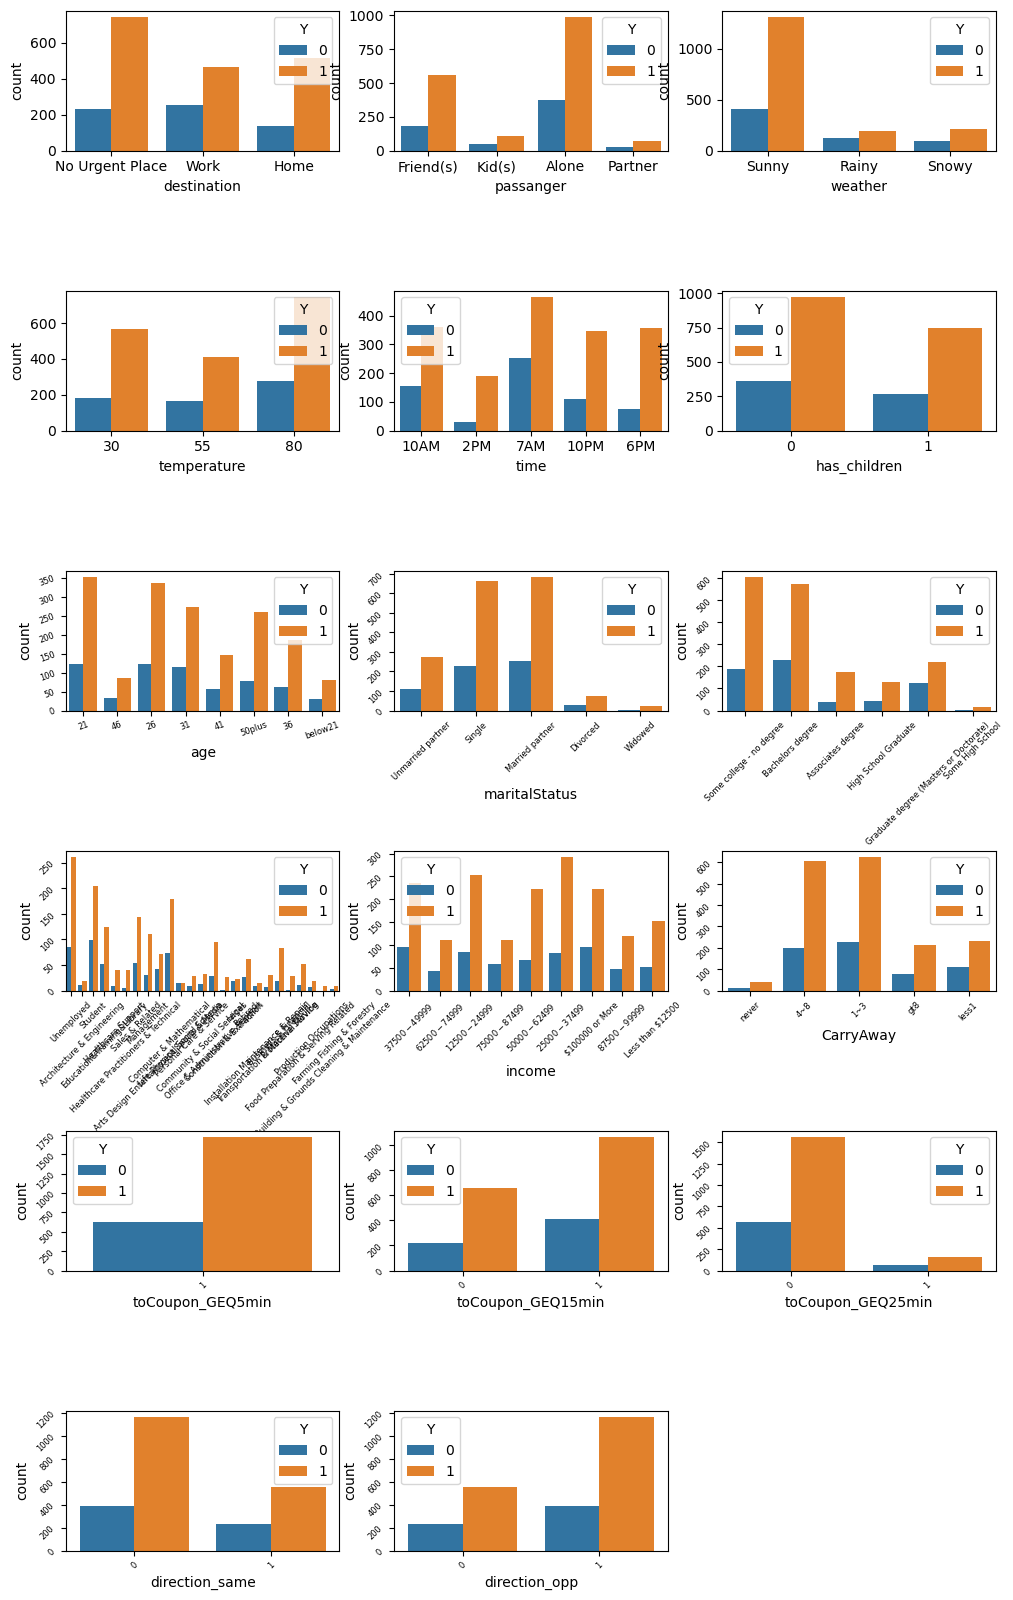

In [901]:
#sns.countplot(data, y="Y", hue="coupon")
# looking at the count plot it looks like carry Away has the most benefit from having coupon
# so I am going to investigate this coupon
print(data.value_counts('coupon', dropna=False))
data_CarryAwayCoupon= data[(data["coupon"] == "Carry out & Take away")]
data_CarryAwayCoupon.head(5)


plt.figure(figsize=(12,20))
plt.subplots_adjust(hspace=1)
plt.tight_layout()
plt.subplot(631)
sns.countplot(data=data_CarryAwayCoupon, x="destination", hue="Y")

plt.subplot(632)
sns.countplot(data=data_CarryAwayCoupon, x="passanger", hue="Y")

plt.subplot(633)
sns.countplot(data=data_CarryAwayCoupon, x="weather", hue="Y")

plt.subplot(634)
sns.countplot(data=data_CarryAwayCoupon, x="temperature", hue="Y")

plt.subplot(635)
sns.countplot(data=data_CarryAwayCoupon, x="time", hue="Y")

plt.subplot(636)
sns.countplot(data=data_CarryAwayCoupon, x="has_children", hue="Y")

ax = plt.subplot(637)
ax.tick_params(labelrotation=20, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="age", hue="Y")

ax = plt.subplot(638)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="maritalStatus", hue="Y")

ax =plt.subplot(639)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="education", hue="Y")

ax = plt.subplot(6, 3, 10)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="occupation", hue="Y")

ax = plt.subplot(6, 3, 11)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="income", hue="Y")

ax = plt.subplot(6, 3, 12)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="CarryAway", hue="Y")

ax = plt.subplot(6, 3, 13)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="toCoupon_GEQ5min", hue="Y")

ax = plt.subplot(6, 3, 14)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="toCoupon_GEQ15min", hue="Y")

ax = plt.subplot(6, 3, 15)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="toCoupon_GEQ25min", hue="Y")

ax = plt.subplot(6, 3, 16)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="direction_same", hue="Y")

ax = plt.subplot(6, 3, 17)
ax.tick_params(labelrotation=45, labelsize=6)
sns.countplot(data=data_CarryAwayCoupon, x="direction_opp", hue="Y")

In [902]:
# looking at the result of count plot of all the relevant variables against drivers accepted coupon and at least visited once 
#lets do similar analysis for CarryAway
print(data_CarryAwayCoupon.value_counts('CarryAway', dropna=False))

CarryAway
1~3      849
4~8      804
less1    346
gt8      293
never     52
Name: count, dtype: int64


In [903]:
# What proportion of CarryAway coupons were accepted?

data_CarryAwayCoupon.query('Y==1')['Y'].count()/data_CarryOut.shape[0]

np.float64(0.7337883959044369)

In [904]:
# Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.

# assuming fewer includes never
fewerthan3_Or3 = ['never', 'less1', '1~3']
CarryAway_3Orfewer_count = data_CarryAwayCoupon.query('CarryAway in @fewerthan3_Or3 and Y == 1')['Y'].count()
morethan3_count = data_CarryAwayCoupon.query('CarryAway not in @fewerthan3_Or3 and Y == 1')['Y'].count()

acceptance_rate_fewer3included = CarryAway_3Orfewer_count/data_CarryAwayCoupon.query('Y == 1')['Y'].count()
acceptance_rate_morethan3 = morethan3_count/data_CarryAwayCoupon.query('Y == 1')['Y'].count()

print('CarryAway accceptance rate for 3 or fewer is: ' + acceptance_rate_fewer3included.astype(str))
print('CarryAway accceptance rate for more than 3  : ' + acceptance_rate_morethan3.astype(str))
print('Acceptance rate : ' + (acceptance_rate_fewer3included/acceptance_rate_morethan3).astype(str))

# not accepting the coupon
CarryAway_3Orfewer_count = data_CarryAwayCoupon.query('CarryAway in @fewerthan3_Or3 and Y == 0')['Y'].count()
morethan3_count = data_CarryAwayCoupon.query('CarryAway not in @fewerthan3_Or3 and Y == 0')['Y'].count()

acceptance_rate_fewer3included = CarryAway_3Orfewer_count/data_CarryAwayCoupon.query('Y == 0')['Y'].count()
acceptance_rate_morethan3 = morethan3_count/data_CarryAwayCoupon.query('Y == 0')['Y'].count()

print('CarryAway not accceptance rate for 3 or fewer is: ' + acceptance_rate_fewer3included.astype(str))
print('CarryAway not accceptance rate for more than 3  : ' + acceptance_rate_morethan3.astype(str))
print('Not Acceptance rate : ' + (acceptance_rate_fewer3included/acceptance_rate_morethan3).astype(str))

CarryAway accceptance rate for 3 or fewer is: 0.5226744186046511
CarryAway accceptance rate for more than 3  : 0.47732558139534886
Acceptance rate : 1.0950060901339829
CarryAway not accceptance rate for 3 or fewer is: 0.5576923076923077
CarryAway not accceptance rate for more than 3  : 0.4423076923076923
Not Acceptance rate : 1.2608695652173914


In [905]:
# Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others. Is there a difference?
# The data is confusing as it has field "less1", the question is how can someone attend a bar less than one since its either you go or don't.
# I am making an assumption that 'less1' represent one time visit , and '1~3' to be more than 1 to 3 times
more_than_1 = ['1~3', '4~8', 'gt8']
age_more_than_25 = ['26', '31', '36', '41', '46', '50plus']
CarryAway_More_than_one = data_CarryAwayCoupon.query('CarryAway in @more_than_1 and Y == 1 and age in @age_more_than_25')['Y'].count()
CarryAway_others = data_CarryAwayCoupon.query('CarryAway in ["never", "less1"] and Y == 1 and age in ["below21", "21"]')['Y'].count()

acceptance_rate_CarryAway_More_than_one = CarryAway_More_than_one/data_CarryOut.query('Y == 1')['Y'].count()
acceptance_rate_CarryAway_others = CarryAway_others/data_CarryAwayCoupon.query('Y == 1')['Y'].count()

print('CarryAway accceptance rate going more than once and over 25            : ' + acceptance_rate_CarryAway_More_than_one.astype(str))
print('CarryAway accceptance rate going one time or less with age less than 25: ' + acceptance_rate_CarryAway_others.astype(str))
print('Acceptance rate : ' + (CarryAway_More_than_one/CarryAway_others).astype(str))

#not accepting coupon
CarryAway_More_than_one = data_CarryAwayCoupon.query('CarryAway in @more_than_1 and Y == 0 and age in @age_more_than_25')['Y'].count()
CarryAway_others = data_CarryAwayCoupon.query('CarryAway in ["never", "less1"] and Y == 0 and age in ["below21", "21"]')['Y'].count()

acceptance_rate_CarryAway_More_than_one = CarryAway_More_than_one/data_CarryOut.query('Y == 0')['Y'].count()
acceptance_rate_CarryAway_others = CarryAway_others/data_CarryAwayCoupon.query('Y == 0')['Y'].count()

print('CarryAway not accceptance rate going more than once and over 25            : ' + acceptance_rate_CarryAway_More_than_one.astype(str))
print('CarryAway not accceptance rate going one time or less with age less than 25: ' + acceptance_rate_CarryAway_others.astype(str))
print('Not Acceptance rate : ' + (CarryAway_More_than_one/CarryAway_others).astype(str))

CarryAway accceptance rate going more than once and over 25            : 0.6343023255813953
CarryAway accceptance rate going one time or less with age less than 25: 0.04534883720930233
Acceptance rate : 13.987179487179487
CarryAway not accceptance rate going more than once and over 25            : 0.594551282051282
CarryAway not accceptance rate going one time or less with age less than 25: 0.038461538461538464
Not Acceptance rate : 15.458333333333334


In [906]:
# Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had 
# passengers that were not a kid and had occupations other than farming, fishing, or forestry.

more_than_1 = ['1~3', '4~8', 'gt8']
CarryAway_Morethan1_nokid_noFarm = data_CarryAwayCoupon.query('CarryAway in @more_than_1 and Y == 1 and passanger not in "Kid(s)" and occupation not in "Farming Fishing & Forestry"')
CarryAway_1OrLess_kid_Farm = data_CarryAwayCoupon.query('CarryAway not in @more_than_1 and Y == 1 and passanger in "Kid(s)" and occupation in "Farming Fishing & Forestry"')

acceptance_rate_CarryAway_Morethan1_nokid_noFarm = CarryAway_Morethan1_nokid_noFarm['Y'].count()/data_CarryAwayCoupon.query('Y == 1')['Y'].count()
acceptance_CarryAway_1OrLess_kid_Farm = CarryAway_1OrLess_kid_Farm['Y'].count()/data_CarryAwayCoupon.query('Y == 1')['Y'].count()


print('CarryAway accceptance rate going more than once, no kids, not farming : ' + acceptance_rate_CarryAway_Morethan1_nokid_noFarm.astype(str))
print('CarryAway accceptance rate going once or less, with kids and farming : ' + acceptance_CarryAway_1OrLess_kid_Farm .astype(str))
print('Acceptance rate : ' + (CarryAway_Morethan1_nokid_noFarm['Y'].count()/CarryAway_1OrLess_kid_Farm['Y'].count()).astype(str))

#not accepting coupon
CarryAway_Morethan1_nokid_noFarm = data_CarryAwayCoupon.query('CarryAway in @more_than_1 and Y == 0 and passanger not in "Kid(s)" and occupation not in "Farming Fishing & Forestry"')
CarryAway_1OrLess_kid_Farm = data_CarryAwayCoupon.query('CarryAway not in @more_than_1 and Y == 0 and passanger in "Kid(s)"')

acceptance_rate_CarryAway_Morethan1_nokid_noFarm = CarryAway_Morethan1_nokid_noFarm['Y'].count()/data_CarryAwayCoupon.query('Y == 0')['Y'].count()
acceptance_CarryAway_1OrLess_kid_Farm = CarryAway_1OrLess_kid_Farm ['Y'].count()/data_CarryAwayCoupon.query('Y == 0')['Y'].count()

print('CarryAway not accceptance rate going more than once, no kids, not farming : ' + acceptance_rate_CarryAway_Morethan1_nokid_noFarm.astype(str))
print('CarryAway not accceptance rate going once or less, with kids and farming : ' + acceptance_CarryAway_1OrLess_kid_Farm .astype(str))
print('Not Acceptance rate : ' + (acceptance_rate_CarryAway_Morethan1_nokid_noFarm/acceptance_CarryAway_1OrLess_kid_Farm).astype(str))


CarryAway accceptance rate going more than once, no kids, not farming : 0.7912790697674419
CarryAway accceptance rate going once or less, with kids and farming : 0.0011627906976744186
Acceptance rate : 680.5
CarryAway not accceptance rate going more than once, no kids, not farming : 0.7451923076923077
CarryAway not accceptance rate going once or less, with kids and farming : 0.014423076923076924
Not Acceptance rate : 51.666666666666664


In [907]:
#Compare the acceptance rates between those drivers who:
#go to bars more than once a month, had passengers that were not a kid, and were not widowed OR
#go to bars more than once a month and are under the age of 30 OR
#go to cheap restaurants more than 4 times a month and income is less than 50K.

more_than_1 = ['1~3', '4~8', 'gt8']
income_list = ["Less than $12500", "$12500 - $24999", "25000 - $37499", "$37500 - $49999"]
total_accepted_count = (data_CarryAwayCoupon[data_CarryAwayCoupon["Y"] ==1])['Y'].count()

rate_CarryAway_NoKid_NotWidow = data_CarryAwayCoupon.query('Bar in @more_than_1 and Y == 1 and passanger not in "Kid(s)" and maritalStatus not in "widowed"')['Y'].count()/ total_accepted_count
rate_CarryAway_bellow21 = data_CarryAwayCoupon.query('Bar in @more_than_1 and Y == 1 and age in ["below21", "21", "26"]')['Y'].count()/total_accepted_count
rate_CheapResturant_income = data_CarryAwayCoupon.query('RestaurantLessThan20 in ["4~8","gt8"] and Y == 1 and income in @income_list')['Y'].count()/total_accepted_count

print('CarryAway accceptance rate going more than once, no kids, not widow : ' + rate_CarryAway_NoKid_NotWidow.astype(str))
print('CarryAway accceptance rate going more than once, age less than 21  : ' + rate_CarryAway_bellow21.astype(str))
print('Cheap Resturant less than 4 times and income less than 50k    : ' + rate_CheapResturant_income.astype(str))

# Not accepting coupon
total_accepted_count = (data_CarryAwayCoupon[data_CarryAwayCoupon["Y"] ==1])['Y'].count()

rate_CarryAway_NoKid_NotWidow = data_CarryAwayCoupon.query('Bar in @more_than_1 and Y == 0 and passanger not in "Kid(s)" and maritalStatus not in "widowed"')['Y'].count()/ total_accepted_count
rate_CarryAway_bellow21 = data_CarryAwayCoupon.query('Bar in @more_than_1 and Y == 0 and age in ["below21", "21", "26"]')['Y'].count()/total_accepted_count
rate_CheapResturant_income = data_CarryAwayCoupon.query('RestaurantLessThan20 in ["4~8","gt8"] and Y == 0 and income in @income_list')['Y'].count()/total_accepted_count

print('CarryAway not accceptance rate going more than once, no kids, not widow : ' + rate_CarryAway_NoKid_NotWidow.astype(str))
print('CarryAway not accceptance rate going more than once, age less than 21  : ' + rate_CarryAway_bellow21.astype(str))
print('Cheap Resturant not acceptance less than 4 times and income less than 50k    : ' + rate_CheapResturant_income.astype(str))



CarryAway accceptance rate going more than once, no kids, not widow : 0.2941860465116279
CarryAway accceptance rate going more than once, age less than 21  : 0.1755813953488372
Cheap Resturant less than 4 times and income less than 50k    : 0.1436046511627907
CarryAway not accceptance rate going more than once, no kids, not widow : 0.1063953488372093
CarryAway not accceptance rate going more than once, age less than 21  : 0.06511627906976744
Cheap Resturant not acceptance less than 4 times and income less than 50k    : 0.045930232558139536
